Import libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

1. Read a local file called “wfa_girls_0-to-13-weeks_zscores.xlsx" into a dataframe.

In [2]:
# Load the Excel file into a DataFrame
df = pd.read_excel("wfa_girls_0-to-13-weeks_zscores.xlsx")

2. Look at the top and bottom 5 rows of the data using head() and tail().

In [3]:
# Look at the top and bottom 5 rows of the data using head() and tail().

# Display the first five rows
df.head(5)

,Week,L,M,S,SD3neg,SD2neg,SD1neg,SD0,SD1,SD2,SD3
0,0,0.3809,3.2322,0.14171,2.0,2.4,2.8,3.2,3.7,4.2,4.8
1,1,0.2671,3.3388,0.14600,2.1,2.5,2.9,3.3,3.9,4.4,5.1
2,2,0.2304,3.5693,0.14339,2.3,2.7,3.1,3.6,4.1,4.7,5.4
3,3,0.2024,3.8352,0.14060,2.5,2.9,3.3,3.8,4.4,5.0,5.7
4,4,0.1789,4.0987,0.13805,2.7,3.1,3.6,4.1,4.7,5.4,6.1


In [4]:
# Display the last few rows
df.tail(5)

,Week,L,M,S,SD3neg,SD2neg,SD1neg,SD0,SD1,SD2,SD3
9,9,0.0918,5.1842,0.12966,3.5,4.0,4.6,5.2,5.9,6.7,7.6
10,10,0.0779,5.3618,0.12861,3.6,4.1,4.7,5.4,6.1,6.9,7.8
11,11,0.0648,5.5295,0.12770,3.8,4.3,4.9,5.5,6.3,7.1,8.1
12,12,0.0525,5.6883,0.12691,3.9,4.4,5.0,5.7,6.5,7.3,8.3
13,13,0.0407,5.8393,0.12622,4.0,4.5,5.1,5.8,6.6,7.5,8.5


3. Plot Week vs SD0.

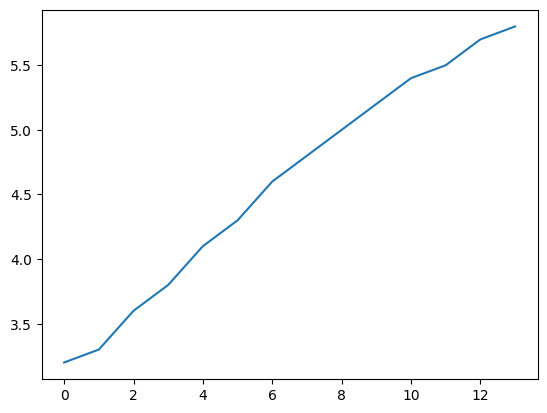

In [5]:
# Plot Week vs SD0
plt.figure()
plt.plot(df['Week'], df['SD0'])

4. Assign suitable axis labels to the plot.

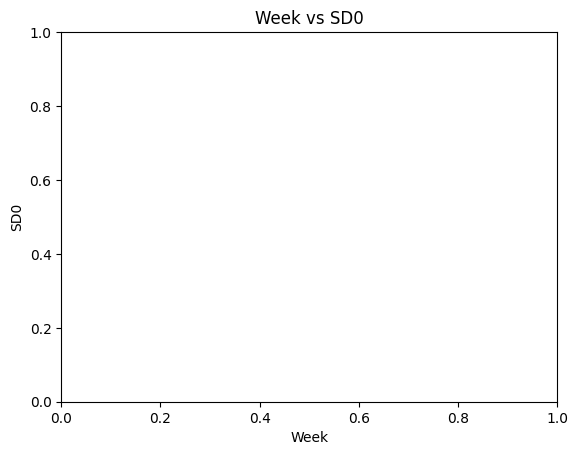

In [6]:
# Add labels and title
plt.xlabel('Week')
plt.ylabel('SD0')
plt.title('Week vs SD0')

# Show the plot
plt.show()

5. Plot day vs SD0, SD1, and SD1neg.

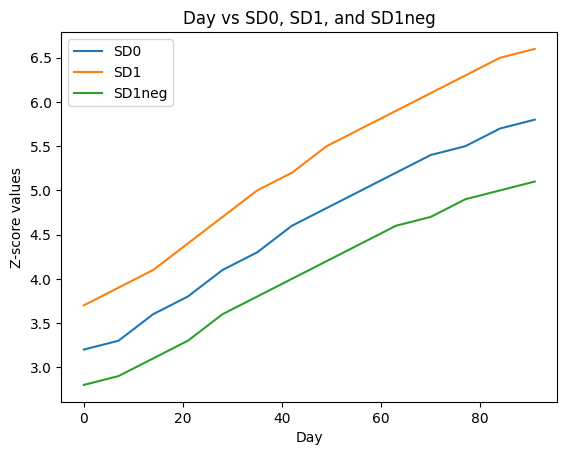

In [7]:
# Create a Day column from Week
df['Day'] = df['Week'] * 7

# Plot Day vs SD0, SD1, and SD1neg
plt.figure()

plt.plot(df['Day'], df['SD0'], label='SD0')
plt.plot(df['Day'], df['SD1'], label='SD1')
plt.plot(df['Day'], df['SD1neg'], label='SD1neg')

# Labels and title
plt.xlabel('Day')
plt.ylabel('Z-score values')
plt.title('Day vs SD0, SD1, and SD1neg')

plt.legend()
plt.show()

6. Save the plot as an image. The format of the image is unimportant, experiment with the options.

In [8]:
plt.savefig('week_vs_sd0.png')

<Figure size 640x480 with 0 Axes>

7. Scale any SD column by a factor of 100. 

In [9]:
# I tried to scale SD0, SD1, SD2

# List of SD columns
sd_columns = ['SD0', 'SD1', 'SD2']

# Scale them by 100
df[sd_columns] = df[sd_columns] * 100

# Verify the changes
print(df[sd_columns].head())

     SD0    SD1    SD2
0  320.0  370.0  420.0
1  330.0  390.0  440.0
2  360.0  410.0  470.0
3  380.0  440.0  500.0
4  410.0  470.0  540.0


8. Change all the column headings to lower case.

In [10]:
# Convert column names to lowercase
df.columns = df.columns.str.lower()

# Verify the changes
print(df.columns)

Index(['week', 'l', 'm', 's', 'sd3neg', 'sd2neg', 'sd1neg', 'sd0', 'sd1',
       'sd2', 'sd3', 'day'],
      dtype='object')


9. Sort all data by descending week.

In [11]:
# Sort by week (descending)
df = df.sort_values(by='week', ascending=False)

# View the result
print(df.head())

    week       l       m        s  sd3neg  sd2neg  sd1neg    sd0    sd1  \
13    13  0.0407  5.8393  0.12622     4.0     4.5     5.1  580.0  660.0   
12    12  0.0525  5.6883  0.12691     3.9     4.4     5.0  570.0  650.0   
11    11  0.0648  5.5295  0.12770     3.8     4.3     4.9  550.0  630.0   
10    10  0.0779  5.3618  0.12861     3.6     4.1     4.7  540.0  610.0   
9      9  0.0918  5.1842  0.12966     3.5     4.0     4.6  520.0  590.0   

      sd2  sd3  day  
13  750.0  8.5   91  
12  730.0  8.3   84  
11  710.0  8.1   77  
10  690.0  7.8   70  
9   670.0  7.6   63  


10. Find the index and value of the min, mean, and max values in the S column. (See section 5.3 and 5.3 in “ch5” notebook)

In [12]:
# Minimum value and its index
min_value = df['s'].min()
min_index = df['s'].idxmin()

# Maximum value and its index
max_value = df['s'].max()
max_index = df['s'].idxmax()

# Mean value
mean_value = df['s'].mean()

print("Minimum value:", min_value, "at index:", min_index)
print("Mean value:", mean_value)
print("Maximum value:", max_value, "at index:", max_index)

Minimum value: 0.12622 at index: 13
Mean value: 0.13441071428571424
Maximum value: 0.146 at index: 1


11. Calculate the percent change of any SD column and save the result as a new dataframe column 
named "PCSDx".

In [13]:
# Use column is sd0 to calculate the percent change and create a new column called PCSDx
df['PCSDx'] = df['sd0'].pct_change() * 100  # multiply by 100 to get percent
# View the new column
print(df[['sd0', 'PCSDx']].head())

      sd0     PCSDx
13  580.0       NaN
12  570.0 -1.724138
11  550.0 -3.508772
10  540.0 -1.818182
9   520.0 -3.703704


12. Write the dataframe to a file named “tutorial2.csv”.

In [14]:
df.to_csv("tutorial2.csv", index=False)

13. Confirm the image and csv files you generated are as you expect.

In [15]:
# Load the saved CSV
df_check = pd.read_csv("tutorial2.csv")

# Preview the data
print(df_check.head())

# Check structure
print(df_check.info())

   week       l       m        s  sd3neg  sd2neg  sd1neg    sd0    sd1    sd2  \
0    13  0.0407  5.8393  0.12622     4.0     4.5     5.1  580.0  660.0  750.0   
1    12  0.0525  5.6883  0.12691     3.9     4.4     5.0  570.0  650.0  730.0   
2    11  0.0648  5.5295  0.12770     3.8     4.3     4.9  550.0  630.0  710.0   
3    10  0.0779  5.3618  0.12861     3.6     4.1     4.7  540.0  610.0  690.0   
4     9  0.0918  5.1842  0.12966     3.5     4.0     4.6  520.0  590.0  670.0   

   sd3  day     PCSDx  
0  8.5   91       NaN  
1  8.3   84 -1.724138  
2  8.1   77 -3.508772  
3  7.8   70 -1.818182  
4  7.6   63 -3.703704  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   week    14 non-null     int64  
 1   l       14 non-null     float64
 2   m       14 non-null     float64
 3   s       14 non-null     float64
 4   sd3neg  14 non-null     float64
 5   sd

14. Export your notebook to pdf.